# Problem definition: Classification of Amyloid PET images into healthy and AD.


In this jupyter notebook, you will learn to classify Amyloid PET images into healthy/congitively normal (CN) and Alzheimer's disease (AD) by using transfer learning using a pre-trained network.


You will learn 2 ways of customizing a pre-trained network:
1. Feature extraction: Use the representations learnt by the pre-trained model to extract features from the new images. You just add a classifer layer which will be trained from scratch on top of the pretrained model. You do not need to retrain the entire model.
2. Fine-tuning: Unfreeze few top layers of the frozen model and jointly train with the newly added classifier layer and the last layers of the base model.This allows us to "fine-tune" the higher order representations in the base model to make it more suitable for the task in hand. .  


**Objectivies (What will we learn here?)**

1. Setting up the env
2. Create training, validation and test ids
3. Image pre-processing
4. Image augmentation
5. Building the classification model
6. Feature extraction
7. Looking at learning curves
8. Fine-tuning
9. Looking at the learning curves
10. Predicting using the build model
11. What next? It is time to play!

## Step 1: Set up the env

In [1]:
# Importing necessary libraries for building and training neural networks
import os
import numpy as np  # For numerical operations with arrays
import pandas as pd  # For data manipulation and analysis
import matplotlib.pyplot as plt  # For plotting graphs and visualizations
from pathlib import Path  # For managing file paths
import torch  # Core PyTorch library for building neural networks
import torch.nn as nn  # Provides modules and classes for neural network layers
import torch.optim as optim  # Contains optimization algorithms like SGD and Adam
from torch.utils.data import DataLoader, Dataset  # Data loading utilities
from torchvision import models, transforms  # Pre-trained models and image transformations
from sklearn.model_selection import train_test_split  # For splitting data into training and test sets
from sklearn.utils import shuffle  # For shuffling the data
from skimage.color import gray2rgb
from PIL import Image

Let's install pydicom which is the library we will use for reading dicom images

In [2]:
!pip install pydicom #python tool for parsing digital images in medicine

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 32.0 MB/s eta 0:00:00


In [3]:
import pydicom

Because we are working on data stored in Google Cloud Storage bucket, the following steps will need to be taken:

Install gcsfuse it is a package used to mount the cloud bucket on to your local environment.

1. Authenticate your google account

2. Create a new directory to mount the storage bucket

3. Use gcsfuse to mount the storage bucket

4. You can browse throught the storage bucket here

In [4]:
!apt-get update -y && apt-get install -y fuse lsb-release; \
    curl -L -O https://github.com/GoogleCloudPlatform/gcsfuse/releases/download/v1.4.0/gcsfuse_1.4.0_amd64.deb; \
    dpkg --install gcsfuse_1.4.0_amd64.deb; \
    apt-get update; \
    apt-get clean;

Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:2 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Hit:3 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:4 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:5 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:6 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:7 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [1,351 kB]
Get:8 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Hit:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:10 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Get:11 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [8,714 kB]
Hit:12 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:13 http://archive.ubuntu.com/ubuntu jammy-upda

Now call google authentication with the following code block and allow access in the pop-up window

In [5]:
from google.colab import auth
auth.authenticate_user()

Let's set the project id and storage bucket id

In [6]:
project_id = 'sfsu-378805'
bucket_name = 'csc-509-image-files'
!gcloud config set project {project_id}

Are you sure you wish to set property [core/project] to sfsu-378805?

Do you want to continue (Y/n)?  Y

Updated property [core/project].


You can list using gsutil to see if we have the correct storage

In [7]:
!gsutil ls

You are attempting to access protected data with no configured
credentials. Please visit https://cloud.google.com/console#/project
and sign up for an account, and then run the "gcloud auth login"
command to configure gsutil to use these credentials.


Let's make a new directory called images to mount our bucket

In [8]:
!mkdir images

Call gcsfuse to mount the bucket

In [9]:
!gcsfuse --implicit-dirs csc-509-image-files images

{"time":"06/03/2025 01:22:04.338091","severity":"INFO","msg":"Start gcsfuse/1.4.0 (Go version go1.21.5) for app \"\" using mount point: /content/images\n"}


In [10]:
!ls images/

Archive				Module0_UPENNGBM  Module1_BraTS.tar.bz2  Module2_ADNI_New
Module0_DataCuration		Module1_ADNI	  Module1_PET
Module0_MRI_PET_Classification	Module1_BraTS	  Module2_ADNI


In [11]:
!pwd #presentworkingdirectory

/content


## Step 2: Now let's create the training, validation and test ids.

In [12]:
# Define where the image data is located
DATA_PATH = Path('/content/images/Module1_PET/PET/')
csv_file = '/content/images/Module1_PET/adni_pet_metadata_file.csv' #this file is going to be the one similar to the notebook 1, this file is now just under a module1_PET


In [13]:
# Load metadata about the images into a DataFrame
data_df = pd.read_csv(csv_file)

In [19]:
data_df.head()

,group,folder,n_images,middle_slice_index,subject_id,image_id,middle_slice,copied_from,copied_from1,copied_from2,copied_from3,copied_from4,copied_from5,copied_from6,file_exists
0,CN,AD_CN_baseline_Uniform_Resolution/CN/941_S_437...,96,48,941_S_4376,I283676,AD_CN_baseline_Uniform_Resolution/CN/941_S_437...,ADNI2_baseline_AV45_PET/941_S_4376/AV45_Coreg,_Avg,_Std_Img_and_Vox_Siz,_Uniform_Resolution/2012-02-03_15_17_12.0/I283...,_Avg,_Std_Img_and_Vox_Siz,_Uniform_Resolution_Br_20120209140414341_48_S1...,1
1,CN,AD_CN_baseline_Uniform_Resolution/CN/941_S_436...,96,48,941_S_4365,I276956,AD_CN_baseline_Uniform_Resolution/CN/941_S_436...,ADNI2_baseline_AV45_PET/941_S_4365/AV45_Coreg,_Avg,_Std_Img_and_Vox_Siz,_Uniform_Resolution/2012-01-06_15_23_36.0/I276...,_Avg,_Std_Img_and_Vox_Siz,_Uniform_Resolution_Br_20120110093755859_48_S1...,1
2,CN,AD_CN_baseline_Uniform_Resolution/CN/941_S_429...,96,48,941_S_4292,I278427,AD_CN_baseline_Uniform_Resolution/CN/941_S_429...,ADNI2_baseline_AV45_PET/941_S_4292/AV45_Coreg,_Avg,_Std_Img_and_Vox_Siz,_Uniform_Resolution/2012-01-11_15_15_55.0/I278...,_Avg,_Std_Img_and_Vox_Siz,_Uniform_Resolution_Br_20120117134415635_48_S1...,1
3,CN,AD_CN_baseline_Uniform_Resolution/CN/941_S_425...,96,48,941_S_4255,I268135,AD_CN_baseline_Uniform_Resolution/CN/941_S_425...,ADNI2_baseline_AV45_PET/941_S_4255/AV45_Coreg,_Avg,_Std_Img_and_Vox_Siz,_Uniform_Resolution/2011-11-18_15_45_01.0/I268...,_Avg,_Std_Img_and_Vox_Siz,_Uniform_Resolution_Br_20111122163122657_48_S1...,1
4,CN,AD_CN_baseline_Uniform_Resolution/CN/941_S_410...,96,48,941_S_4100,I257617,AD_CN_baseline_Uniform_Resolution/CN/941_S_410...,ADNI2_baseline_AV45_PET/941_S_4100/AV45_Coreg,_Avg,_Std_Img_and_Vox_Siz,_Uniform_Resolution/2011-09-16_15_07_08.0/I257...,_Avg,_Std_Img_and_Vox_Siz,_Uniform_Resolution_Br_20110923133245628_48_S1...,1


In [14]:
!ls /content/images/Module1_PET/PET/AD_CN_baseline_Uniform_Resolution/AD/ | wc -l #wordcount of all of the files (pipe operation)


141


In [15]:
!ls /content/images/Module1_PET/PET/AD_CN_baseline_Uniform_Resolution/CN/ | wc -l


181


In [16]:
data_df.subject_id.nunique() #8 missing subject IDs

330

In [17]:

def check_middle_slice_exists(data_df):
    file_exists_list = [] #empty list
    for index, row in data_df.iterrows():
        if index % 10 == 0: #if the remainder equals zero, the middle slice was found
            print(index)
        path = os.path.join(DATA_PATH, row["middle_slice"])
        if os.path.exists(path):
            file_exists_list.append(1)
        else:
            print(f"Middle slice not found for: {row['middle_slice']}")
            file_exists_list.append(0)
    data_df['file_exists'] = file_exists_list
    return data_df


In [18]:
data_df = check_middle_slice_exists(data_df)

0
10
20
30
40
50
60
70
80
90
100
110
120
130
140
150
160
170
180
190
200
210
220
230
Middle slice not found for: AD_CN_baseline_Uniform_Resolution/AD/073_S_5016_I365866/PET_Slice_048.dcm
240
250
260
270
Middle slice not found for: AD_CN_baseline_Uniform_Resolution/AD/024_S_4280_I265274/PET_Slice_048.dcm
280
290
300
Middle slice not found for: AD_CN_baseline_Uniform_Resolution/AD/009_S_5224_I386055/PET_Slice_048.dcm
310
Middle slice not found for: AD_CN_baseline_Uniform_Resolution/AD/006_S_4546_I300104/PET_Slice_048.dcm
Middle slice not found for: AD_CN_baseline_Uniform_Resolution/AD/006_S_4192_I268115/PET_Slice_048.dcm
320
Middle slice not found for: AD_CN_baseline_Uniform_Resolution/AD/005_S_4910_I342830/PET_Slice_048.dcm
Middle slice not found for: AD_CN_baseline_Uniform_Resolution/AD/003_S_4373_I282305/PET_Slice_048.dcm
Middle slice not found for: AD_CN_baseline_Uniform_Resolution/AD/002_S_5018_I347760/PET_Slice_048.dcm


In [20]:
data_df = data_df.drop(data_df[data_df['file_exists'] == 0].index)

In [24]:
data_df.head(-1)

,group,folder,n_images,middle_slice_index,subject_id,image_id,middle_slice,copied_from,copied_from1,copied_from2,copied_from3,copied_from4,copied_from5,copied_from6,file_exists
0,CN,AD_CN_baseline_Uniform_Resolution/CN/941_S_437...,96,48,941_S_4376,I283676,AD_CN_baseline_Uniform_Resolution/CN/941_S_437...,ADNI2_baseline_AV45_PET/941_S_4376/AV45_Coreg,_Avg,_Std_Img_and_Vox_Siz,_Uniform_Resolution/2012-02-03_15_17_12.0/I283...,_Avg,_Std_Img_and_Vox_Siz,_Uniform_Resolution_Br_20120209140414341_48_S1...,1
1,CN,AD_CN_baseline_Uniform_Resolution/CN/941_S_436...,96,48,941_S_4365,I276956,AD_CN_baseline_Uniform_Resolution/CN/941_S_436...,ADNI2_baseline_AV45_PET/941_S_4365/AV45_Coreg,_Avg,_Std_Img_and_Vox_Siz,_Uniform_Resolution/2012-01-06_15_23_36.0/I276...,_Avg,_Std_Img_and_Vox_Siz,_Uniform_Resolution_Br_20120110093755859_48_S1...,1
2,CN,AD_CN_baseline_Uniform_Resolution/CN/941_S_429...,96,48,941_S_4292,I278427,AD_CN_baseline_Uniform_Resolution/CN/941_S_429...,ADNI2_baseline_AV45_PET/941_S_4292/AV45_Coreg,_Avg,_Std_Img_and_Vox_Siz,_Uniform_Resolution/2012-01-11_15_15_55.0/I278...,_Avg,_Std_Img_and_Vox_Siz,_Uniform_Resolution_Br_20120117134415635_48_S1...,1
3,CN,AD_CN_baseline_Uniform_Resolution/CN/941_S_425...,96,48,941_S_4255,I268135,AD_CN_baseline_Uniform_Resolution/CN/941_S_425...,ADNI2_baseline_AV45_PET/941_S_4255/AV45_Coreg,_Avg,_Std_Img_and_Vox_Siz,_Uniform_Resolution/2011-11-18_15_45_01.0/I268...,_Avg,_Std_Img_and_Vox_Siz,_Uniform_Resolution_Br_20111122163122657_48_S1...,1
4,CN,AD_CN_baseline_Uniform_Resolution/CN/941_S_410...,96,48,941_S_4100,I257617,AD_CN_baseline_Uniform_Resolution/CN/941_S_410...,ADNI2_baseline_AV45_PET/941_S_4100/AV45_Coreg,_Avg,_Std_Img_and_Vox_Siz,_Uniform_Resolution/2011-09-16_15_07_08.0/I257...,_Avg,_Std_Img_and_Vox_Siz,_Uniform_Resolution_Br_20110923133245628_48_S1...,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
316,AD,AD_CN_baseline_Uniform_Resolution/AD/005_S_470...,96,48,005_S_4707,I311316,AD_CN_baseline_Uniform_Resolution/AD/005_S_470...,ADNI2_baseline_AV45_PET/005_S_4707/AV45_Coreg,_Avg,_Std_Img_and_Vox_Siz,_Uniform_Resolution/2012-06-15_14_41_00.0/I311...,_Avg,_Std_Img_and_Vox_Siz,_Uniform_Resolution_Br_20120619172125043_48_S1...,1
317,AD,AD_CN_baseline_Uniform_Resolution/AD/003_S_518...,96,48,003_S_5187,I384407,AD_CN_baseline_Uniform_Resolution/AD/003_S_518...,ADNI2_baseline_AV45_PET/003_S_5187/AV45_Coreg,_Avg,_Std_Img_and_Vox_Siz,_Uniform_Resolution/2013-07-19_14_28_05.0/I384...,_Avg,_Std_Img_and_Vox_Siz,_Uniform_Resolution_Br_20130806084924618_48_S1...,1
318,AD,AD_CN_baseline_Uniform_Resolution/AD/003_S_516...,96,48,003_S_5165,I384740,AD_CN_baseline_Uniform_Resolution/AD/003_S_516...,ADNI2_baseline_AV45_PET/003_S_5165/AV45_Coreg,_Avg,_Std_Img_and_Vox_Siz,_Uniform_Resolution/2013-06-19_14_52_14.0/I384...,_Avg,_Std_Img_and_Vox_Siz,_Uniform_Resolution_Br_20130808084441483_48_S1...,1
319,AD,AD_CN_baseline_Uniform_Resolution/AD/003_S_489...,96,48,003_S_4892,I334488,AD_CN_baseline_Uniform_Resolution/AD/003_S_489...,ADNI2_baseline_AV45_PET/003_S_4892/AV45_Coreg,_Avg,_Std_Img_and_Vox_Siz,_Uniform_Resolution/2012-09-13_15_46_08.0/I334...,_Avg,_Std_Img_and_Vox_Siz,_Uniform_Resolution_Br_20120917111004509_48_S1...,1


In [25]:
data_df = data_df.reset_index(drop =True)

From the data wrangling and preprocessing exercise we have already created a csv with middle slices of the Amyloid PET images. Let's read that csv file.

In [26]:
data_df.head(n=2)

,group,folder,n_images,middle_slice_index,subject_id,image_id,middle_slice,copied_from,copied_from1,copied_from2,copied_from3,copied_from4,copied_from5,copied_from6,file_exists
0,CN,AD_CN_baseline_Uniform_Resolution/CN/941_S_437...,96,48,941_S_4376,I283676,AD_CN_baseline_Uniform_Resolution/CN/941_S_437...,ADNI2_baseline_AV45_PET/941_S_4376/AV45_Coreg,_Avg,_Std_Img_and_Vox_Siz,_Uniform_Resolution/2012-02-03_15_17_12.0/I283...,_Avg,_Std_Img_and_Vox_Siz,_Uniform_Resolution_Br_20120209140414341_48_S1...,1
1,CN,AD_CN_baseline_Uniform_Resolution/CN/941_S_436...,96,48,941_S_4365,I276956,AD_CN_baseline_Uniform_Resolution/CN/941_S_436...,ADNI2_baseline_AV45_PET/941_S_4365/AV45_Coreg,_Avg,_Std_Img_and_Vox_Siz,_Uniform_Resolution/2012-01-06_15_23_36.0/I276...,_Avg,_Std_Img_and_Vox_Siz,_Uniform_Resolution_Br_20120110093755859_48_S1...,1


In [31]:
print(len(data_df))

322


In [27]:
data_df.group.value_counts()

,count
group,
CN,181
AD,141


In [28]:
# Split the list of unique image IDs into train, validation, and test sets
ids = data_df['subject_id'].unique()  # Unique identifiers for images
ids[0] #first patient

'941_S_4376'

In [29]:
train_ids, test_ids = train_test_split(ids, test_size=0.20, random_state=0)  # 20% for testing
train_ids, val_ids = train_test_split(train_ids, test_size=0.20, random_state=0)  # 20% of remaining for validation

In [30]:
print(len(train_ids), len(val_ids), len(test_ids))

205 52 65


## We already understand what each of these groups mean:

- CN : Cognitively normal
- MCI : Mild cognitive impairment
- EMCI : Early mild cognitive impairment
- LMCI: Late mild cognitive impairment
- AD : Alzheimer's disease
- SMC : Significant memory concerns

Spatial pattern of amyloid deposition in AD: https://onlinelibrary.wiley.com/doi/10.1002/hbm.23018

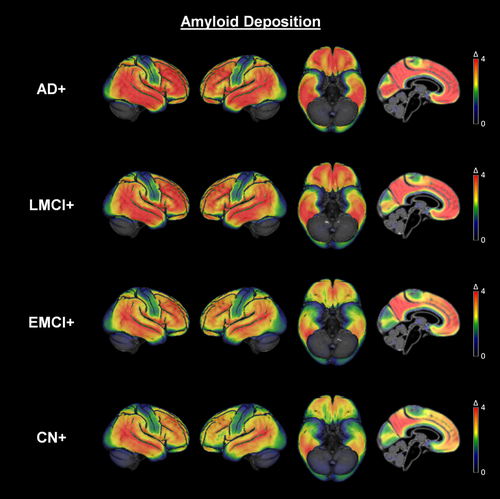



In [32]:
data_df.subject_id.nunique()

322

In [33]:
data_df.shape

(322, 15)

What are types of classification in deep learning: https://machinelearningmastery.com/types-of-classification-in-machine-learning/

About train, validation and test sets: https://towardsdatascience.com/train-validation-and-test-sets-72cb40cba9e7

Scikit-learn train, validation and test splits: https://stackabuse.com/scikit-learns-traintestsplit-training-testing-and-validation-sets/

In [34]:
# Let's check the number of patients ids in train, validation and test set
print(f'There are {len(train_ids)} patient ids in training set')
print(f'There are {len(val_ids)} patient ids in validation set')
print(f'There are {len(test_ids)} patient ids in test set')

There are 205 patient ids in training set
There are 52 patient ids in validation set
There are 65 patient ids in test set


In [35]:
# Let's check the number of CN and AD patients in the splits. We want our splits to be balanced.
data_df['Split'] = np.where(data_df['subject_id'].isin(train_ids), 'Train', '') #accessing a column called split, selects train ID and group by to aggregate
data_df['Split'] = np.where(data_df['subject_id'].isin(val_ids), 'Validation', data_df['Split'])
data_df['Split'] = np.where(data_df['subject_id'].isin(test_ids), 'Test', data_df['Split'])

data_df.groupby(by = ['Split','group'])['subject_id'].agg('nunique').reset_index()
#no training inbalance
#maybe the validation and test have imbalance

,Split,group,subject_id
0,Test,AD,22
1,Test,CN,43
2,Train,AD,105
3,Train,CN,100
4,Validation,AD,14
5,Validation,CN,38


What to do when your train and test data comes from different distributions: https://www.freecodecamp.org/news/what-to-do-when-your-training-and-testing-data-come-from-different-distributions-d89674c6ecd8/

## Step 3: Let's instantiate the pytorch custom imaging dataset and wrap the processing steps within it.

Why do we normalize images for deep learning: https://towardsdatascience.com/why-data-should-be-normalized-before-training-a-neural-network-c626b7f66c7d

How do you know you have enough training data or sample size: https://towardsdatascience.com/how-do-you-know-you-have-enough-training-data-ad9b1fd679ee

Normally, we wrap the loading, normalization, and processing inside the dataset - however, we want you to learn to do these steps manually so we're asking that you instead look at each of the functions separately.

In [45]:
class PETDataset(Dataset): #created in module 0 Notebook 2, grabs and processes images to store them as processed images
    """Custom dataset for loading and preprocessing PET images and labels."""
    def __init__(self, dataframe, data_path, transform=None):
        self.dataframe = dataframe
        self.data_path = data_path
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def dicom_to_pil(self, dicom_path):
        """Converts a DICOM file to a PIL Image.

        Args:
            dicom_path: Path to the DICOM file.

        Returns:
            A PIL Image object, or None if an error occurs.
        """
        try:
            dicom = pydicom.dcmread(dicom_path)
            image = dicom.pixel_array.astype(np.int16)  # Ensure int16

            # Normalize the image to 0-255 range for PIL, generally this library uses grayscale range which is 0-255
            min_val = np.min(image)
            max_val = np.max(image)
            normalized_image = ((image - min_val) / (max_val - min_val) * 255).astype(np.uint8)

            # Convert grayscale to RGB if needed
            if len(normalized_image.shape) == 2:  # Check if grayscale
                pil_image = Image.fromarray(normalized_image, mode='L').convert("RGB")
            else:
              pil_image = Image.fromarray(normalized_image)

            return pil_image
        except Exception as e:
            print(f"Error converting DICOM to PIL: {e}")
            return None

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]


        # Convert label to binary, conversion of categorical variable to numerical one
        label = 0 if row['group'] == 'CN' else 1

        img_path = os.path.join(self.data_path, row['middle_slice'])
        img_pil = self.dicom_to_pil(img_path)

        if self.transform:
            img_pil = self.transform(img_pil)

        return img_pil, label

In [39]:
# Define transformations to apply to images
transform = transforms.Compose([
    transforms.ToTensor(),  # Convert image to PyTorch tensor
    transforms.Resize((224, 224)),  # Resize image
    # transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])  # Normalize image with mean and std
])



In [40]:
train_df = data_df.loc[data_df['Split'] == 'Train']
val_df = data_df.loc[data_df['Split'] == 'Validation']
test_df = data_df.loc[data_df['Split'] == 'Test']

In [41]:
train_dataset = PETDataset(train_df, DATA_PATH, transform=transform)
val_dataset = PETDataset(val_df, DATA_PATH, transform=transform)
test_dataset = PETDataset(test_df, DATA_PATH, transform=transform)

In [42]:
vars(train_dataset).keys() ## Looks at the dataset object and allows you to take a closer look/debug

dict_keys(['dataframe', 'data_path', 'transform'])

In [43]:
train_loader = DataLoader(train_dataset, batch_size = 32, shuffle = True)
val_loader = DataLoader(val_dataset, batch_size = 32, shuffle = False)
test_loader = DataLoader(test_dataset, batch_size = 32, shuffle = False)

In [44]:
x, y = next(iter(train_loader))

<ipython-input-38-419c06b088d6>:27: RuntimeWarning: overflow encountered in scalar subtract
  normalized_image = ((image - min_val) / (max_val - min_val) * 255).astype(np.uint8)


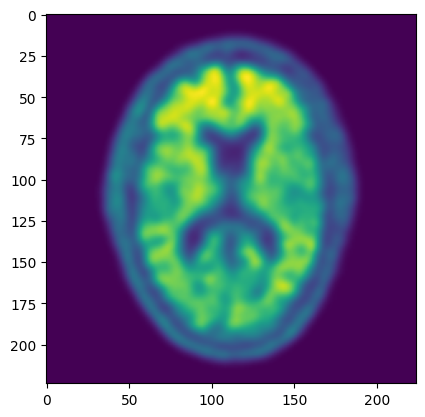

In [46]:
plt.imshow(x[0,0])

It takes a long time to create the numpy arrays. We just want to execute this step once and save the numpy arrays as .npy files so that we can reuse the files for out hyper-parameter tuning.

**Please change the location of the files to your own location. Else you will overwrite the previously created files in the shared folder.**


Now we will read the .npy files and start our model training!We have a numpy arrays already created and saved in the shared folder.

**Please save a copy of the files to your own location and read files from that location.**

In [47]:
# # Let's load the train, validation and test arrays
# X_train = np.load('/content/images/Module2_ADNI/Numpy_files/AmyPET_train_images.npy', allow_pickle=True)
# X_val = np.load('/content/images/Module2_ADNI/Numpy_files/AmyPET_val_images.npy', allow_pickle=True)
# X_test = np.load('/content/images/Module2_ADNI/Numpy_files/AmyPET_test_images.npy', allow_pickle=True)
# Y_train = np.load('/content/images/Module2_ADNI/Numpy_files/AmyPET_train_label.npy', allow_pickle=True)
# Y_val = np.load('/content/images/Module2_ADNI/Numpy_files/AmyPET_val_label.npy', allow_pickle=True)
# Y_test = np.load('/content/images/Module2_ADNI/Numpy_files/AmyPET_test_label.npy', allow_pickle=True)

The images are not 3 channel. Inorder to use Imagenet weights, we will need 3 channel images. The next step converts the images to 3 channel.

What are grayscale abd RGB images: https://www.analyticsvidhya.com/blog/2021/03/grayscale-and-rgb-format-for-storing-images/

In [ ]:
# # Converting grayscale images to RGB
# X_train = np.array([gray2rgb(X_train[i]) for i in range(len(X_train))])
# X_val = np.array([gray2rgb(X_val[i]) for i in range(len(X_val))])
# X_test = np.array([gray2rgb(X_test[i]) for i in range(len(X_test))])

Because we have mulitple images from same patient, we need to shuffle the training set. We will also shuffle the validation and test sets.

Wht shuffling is recommended in deep learning: https://www.deepwizai.com/simply-deep/why-random-shuffling-improves-generalizability-of-neural-nets

Colormaps in matplotlib: https://www.analyticsvidhya.com/blog/2020/09/colormaps-matplotlib/

2 articles on effect of batch size on training:
1. https://machinelearningmastery.com/how-to-control-the-speed-and-stability-of-training-neural-networks-with-gradient-descent-batch-size/#:~:text=Batch%20size%20controls%20the%20accuracy,stability%20of%20the%20learning%20process.

2. https://medium.com/mini-distill/effect-of-batch-size-on-training-dynamics-21c14f7a716e

Optimizing performance with AUTOTUNE: https://towardsdatascience.com/optimising-your-input-pipeline-performance-with-tf-data-part-1-32e52a30cac4

## Step 4: Let's look at image augmentation now.

Augmentation is a technique to increase the diversity of your training set by applying random (but realistic) transformations, such as image rotation. This helps expose the model to different aspects of the training data and reduce overfitting.

Note: Augmentation should be applied only on the training set.

How is augmentation helpful in deep learning: https://nanonets.com/blog/data-augmentation-how-to-use-deep-learning-when-you-have-limited-data-part-2/

Data augmentation using tensorflow: https://www.tensorflow.org/tutorials/images/data_augmentation

In [ ]:
transform_augmented = transforms.Compose([
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomRotation(15, expand=False, center=None),
            transforms.RandomAffine(15, translate = (.05, 0.05)),
            transforms.ColorJitter(brightness = 0.05, contrast = 0.05, saturation = 0.05, hue = 0.05),
            transforms.ToTensor(),
            ])

In [ ]:
train_dataset_augmented = PETDataset(train_df, data_path = DATA_PATH, transform = transform_augmented)

In [ ]:
train_loader_augmented = DataLoader(train_dataset_augmented, batch_size = 1)

In [ ]:
X_aug, y_aug = next(iter(train_loader_augmented))

In [ ]:
X_aug.shape

torch.Size([1, 3, 160, 160])

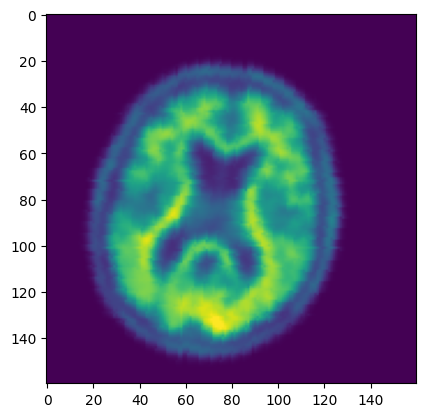

In [ ]:
plt.imshow(X_aug[0,0])

# Step 5: Building the Model with ResNet18 in PyTorch
## 5.1 Understanding  Feature Extraction
In this step, we will use the ResNet18 pre-trained network to extract features from our PET images. This approach leverages the powerful and informative features learned from the ImageNet dataset, which contains 1.4 million images across 1000 different classes. By using a pre-trained model, we can take advantage of this prior knowledge to classify images as Cognitively Normal (CN) or Alzheimer's Disease (AD).

Pre-trained Networks: These are models that have already been trained on large datasets like ImageNet, which consist of a wide variety of categories. Using pre-trained models helps in learning new tasks faster and more accurately because they start with already learned features.

ResNet18: This is one of the many models pre-trained on ImageNet. It is known for its simplicity and effectiveness in extracting features through its residual learning framework. We will use the layer before the final fully connected layer for feature extraction.

Steps to Use ResNet18 in PyTorch
Load Pre-trained ResNet18: We will use PyTorch's torchvision.models to load the ResNet18 model with pre-trained ImageNet weights.
Modify the Model: Remove the top classification layer to use the model for feature extraction.
Normalize Input Data: Ensure input images are normalized to match the expected input format of ResNet18, which is [0, 1].

In [ ]:
# Step 1: Load the pre-trained ResNet18 model
resnet18 = models.resnet18(pretrained=True)

# Step 2: Modify the model for feature extraction
# We don't need the final classification layer, so we'll replace it
# Get the number of input features for the final layer
num_features = resnet18.fc.in_features
# Replace the final fully connected layer with an identity layer for feature extraction
resnet18.fc = nn.Identity()


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 99.4MB/s]


In [ ]:
# Move the model to the appropriate device (GPU if available)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
resnet18.to(device)

# Step 3: Define transformations for input normalization
# ResNet18 expects input images that are normalized to [0, 1]
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize((224, 224)),  # ResNet18 expects 224x224 input size
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])  # Standard normalization for ResNet
])


This feature extractor converts each 3x160x160 image into a 3x3x2048 block of features. Let's see what it does to an example batch of images.

In [ ]:
resnet18._modules['conv1']

Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)

In [ ]:
resnet18._modules['layer1']

Sequential(
  (0): BasicBlock(
    (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (1): BasicBlock(
    (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
)

In [ ]:
# Example: Using the model to extract features from an input batch
def extract_features(loader, model, device):
    model.eval()  # Set the model to evaluation mode
    feature_extractor = model._modules['conv1']
    features = []

    with torch.no_grad():  # Disable gradient calculation
        inputs, gts = next(iter(loader))
        inputs = inputs.to(device)
        # Forward pass through the model to extract features
        outputs = feature_extractor(inputs)
        features.append(outputs.cpu().numpy())

    # Concatenate all features into a single array
    return np.concatenate(features, axis=0)

In [ ]:
# Now you can use the transform to preprocess your data and the function to extract features
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

# Extract features
train_features = extract_features(train_loader, resnet18, device="cuda")


<ipython-input-30-cc998530ced4>:27: RuntimeWarning: overflow encountered in scalar subtract
  normalized_image = ((image - min_val) / (max_val - min_val) * 255).astype(np.uint8)


In [ ]:
train_features.shape ## This is just to illustrate what we are doing -

(32, 64, 80, 80)

# Step 6: Build and train a model with transfer learning

## 6.1 Setup pre-trained model
First, we will set up a pre-trained ResNet18 model. This model has been trained on the ImageNet dataset, which contains 1.4 million images across 1000 classes. We'll modify it for our binary classification task.

Explanation:

* Pre-trained Model: We use ResNet18 because it is smaller and faster than deeper networks, making it ideal for experimentation and learning.
* Freezing Layers: By default, we prevent all layers from being updated during training, which means we are only training the new classification layer.
* Replacement Layer: The final layer is replaced with a single output node and a sigmoid activation, suitable for binary classification tasks.




In [ ]:
# Load the pre-trained ResNet18 model from torchvision
resnet18 = models.resnet18(pretrained=True)

# Get the number of input features for the final layer
num_features = resnet18.fc.in_features

# Freeze all layers in the base model to prevent them from being updated during training
for param in resnet18.parameters():
    param.requires_grad = False

# Replace the final fully connected layer with a new one that outputs a single value for binary classification
resnet18.fc = nn.Sequential(
    nn.Linear(num_features, 1),  # New fully connected layer
    nn.Sigmoid()  # Use sigmoid activation for binary classification
)

# Move the model to the specified device (GPU if available, else CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
resnet18 = resnet18.to(device)

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


## 6.2 Train Feature Extractor

Now, we will train only the new classification layer. This is known as feature extraction because we use the pre-trained network to extract features and only train the top layer.



In [ ]:
# Define loss function and optimizer
criterion = nn.BCELoss()  # Binary cross-entropy loss
optimizer = optim.Adam(resnet18.fc.parameters(), lr=0.0001)  # Adam optimizer with learning rate 0.0001



In [ ]:
# Training loop for feature extraction
num_epochs = 5
for epoch in range(num_epochs):
    resnet18.train()  # Set model to training mode
    running_loss = 0.0

    # Iterate over training data
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device).float().unsqueeze(1)  # Move data to device and adjust shape
        optimizer.zero_grad()  # Clear previous gradients
        outputs = resnet18(inputs)  # Forward pass
        loss = criterion(outputs, labels)  # Compute loss
        loss.backward()  # Backward pass to compute gradients
        optimizer.step()  # Update model weights
        running_loss += loss.item()  # Accumulate loss

    train_loss = running_loss / len(train_loader)  # Compute average training loss

    resnet18.eval()  # Set model to evaluation mode
    val_loss = 0.0
    correct = 0
    with torch.no_grad():  # No gradient computation during evaluation
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device).float().unsqueeze(1)
            outputs = resnet18(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            preds = outputs > 0.5  # Convert outputs to binary predictions
            correct += preds.eq(labels).sum().item()  # Count correct predictions

    val_loss /= len(val_loader)  # Compute average validation loss
    val_accuracy = correct / len(val_loader.dataset)  # Compute validation accuracy
    print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_accuracy:.4f}")

<ipython-input-30-cc998530ced4>:27: RuntimeWarning: overflow encountered in scalar subtract
  normalized_image = ((image - min_val) / (max_val - min_val) * 255).astype(np.uint8)


Epoch 1/5, Train Loss: 0.6987, Val Loss: 0.6932, Val Acc: 0.6731
Epoch 2/5, Train Loss: 0.7201, Val Loss: 0.6912, Val Acc: 0.6923
Epoch 3/5, Train Loss: 0.6754, Val Loss: 0.6848, Val Acc: 0.6923
Epoch 4/5, Train Loss: 0.6783, Val Loss: 0.6631, Val Acc: 0.6731
Epoch 5/5, Train Loss: 0.6863, Val Loss: 0.6468, Val Acc: 0.6731


Explanation:

* Training Mode: resnet18.train() sets the model to training mode, which is important for layers like dropout or batch normalization.
* Adjust Labels: We convert labels to float and adjust their shape to match the model output.
* Gradient Steps: optimizer.zero_grad(), loss.backward(), and optimizer.step() are standard steps to update model weights using gradient descent.
* Evaluation Mode: resnet18.eval() ensures no gradients are computed during validation, saving memory and computations.

# 7. Fine-tuning
Fine-tuning involves unfreezing some of the layers in the pre-trained model and training them along with the classification layer. This can lead to better performance as the model can adjust more of its parameters to the specific task.

## 7.1 Unfreeze layers and continue training
Explanation:

* Unfreezing Layers: This step allows all layers to be updated. The network can now adjust its parameters more thoroughly.
* Learning Rate: We use a smaller learning rate for fine-tuning, as large updates can disrupt the pre-trained weights.

In [ ]:
# Save the metrics
train_losses, val_losses, val_accuracies = [], [], [

# Unfreeze all layers in the base model for fine-tuning
for param in resnet18.parameters():
    param.requires_grad = True

# Use a lower learning rate for fine-tuning
optimizer = optim.Adam(resnet18.parameters(), lr=0.00001)  # Lower learning rate for fine-tuning

# Continue training with fine-tuning
num_epochs_fine = 8
for epoch in range(num_epochs_fine):
    resnet18.train()  # Set model to training mode
    running_loss = 0.0

    # Iterate over training data
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device).float().unsqueeze(1)  # Move data to device and adjust shape
        optimizer.zero_grad()  # Clear previous gradients
        outputs = resnet18(inputs)  # Forward pass
        loss = criterion(outputs, labels)  # Compute loss
        loss.backward()  # Backward pass to compute gradients
        optimizer.step()  # Update model weights
        running_loss += loss.item()  # Accumulate loss

    train_loss = running_loss / len(train_loader)  # Compute average training loss

    resnet18.eval()  # Set model to evaluation mode
    val_loss = 0.0
    correct = 0
    with torch.no_grad():  # No gradient computation during evaluation
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device).float().unsqueeze(1)
            outputs = resnet18(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            preds = outputs > 0.5  # Convert outputs to binary predictions
            correct += preds.eq(labels).sum().item()  # Count correct predictions

    val_loss /= len(val_loader)  # Compute average validation loss
    val_accuracy = correct / len(val_loader.dataset)  # Compute validation accuracy

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)

    print(f"Fine-tuning Epoch {epoch+1}/{num_epochs_fine}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_accuracy:.4f}")

<ipython-input-30-cc998530ced4>:27: RuntimeWarning: overflow encountered in scalar subtract
  normalized_image = ((image - min_val) / (max_val - min_val) * 255).astype(np.uint8)


Fine-tuning Epoch 1/5, Train Loss: 0.6167, Val Loss: 0.6033, Val Acc: 0.6923
Fine-tuning Epoch 2/5, Train Loss: 0.5331, Val Loss: 0.5787, Val Acc: 0.7308


# 8. Visualizing learning curves
Visualizing the learning curves helps us understand how well the model is learning over time. We plot both the training and validation losses, as well as the validation accuracy.

Explanation:

* Plotting: We use Matplotlib to plot the loss and accuracy over epochs. This visual feedback is crucial for diagnosing issues like overfitting or underfitting.
* Legend and Labels: These annotations help interpret the graphs, showing the trends in performance over time.

In [ ]:
def plot_learning_curves():
    """Plot training and validation loss and accuracy over epochs."""
    epochs = range(1, len(train_losses) + 1)
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_losses, 'b-', label='Training Loss')
    plt.plot(epochs, val_losses, 'r-', label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, val_accuracies, 'g-', label='Validation Accuracy')
    plt.title('Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.show()

plot_learning_curves()